<a href="https://colab.research.google.com/github/Vaibhavs1104/Car_Price_Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
import sklearn.datasets
import plotly.express as px
from sklearn.metrics import r2_score
from sklearn import preprocessing

In [ ]:
df=pd.read_csv('/content/car data.csv')

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df['Owner'].value_counts()

,count
Owner,
0,290
1,10
3,1


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
df.duplicated().sum()

2

In [ ]:
df.drop_duplicates()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
top_10_car=df['Car_Name'].value_counts().head(10)
top_10_car

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
ciaz,9
innova,9
i20,9
grand i10,8


In [ ]:
ex=px.bar(top_10_car,color=top_10_car,title='Top 10 car')
ex.show()

In [ ]:
df['Selling_Price'].describe()

,Selling_Price
count,301.000000
mean,4.661296
std,5.082812
min,0.100000
25%,0.900000
50%,3.600000
75%,6.000000
max,35.000000


In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
data=px.scatter(df,x='Selling_Price',y='Car_Name',size='Selling_Price',color='Selling_Price')
data.show()

In [ ]:
df['Present_Price'].describe()

,Present_Price
count,301.000000
mean,7.628472
std,8.644115
min,0.320000
25%,1.200000
50%,6.400000
75%,9.900000
max,92.600000


In [ ]:
data=px.scatter(df,x='Present_Price',y='Car_Name',size='Present_Price',color='Present_Price')
data.show()

In [ ]:
worst_10_car_driven=df[['Car_Name','Kms_Driven']].sort_values(by='Kms_Driven',ascending=False)
worst_10_car_driven

,Car_Name,Kms_Driven
196,Activa 3g,500000
179,Honda Karizma,213000
84,innova,197176
85,camry,142000
77,corolla,135154
...,...,...
126,Bajaj Avenger 220,1300
103,Bajaj Dominar 400,1200
166,Hero Passion Pro,1000
165,Activa 3g,500


In [ ]:
data=px.scatter(worst_10_car_driven,x="Kms_Driven",y="Car_Name",color="Kms_Driven",size="Kms_Driven",title="Number of Kilometres the car is driven")
data.show()

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
x=df['Fuel_Type'].value_counts()
x

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


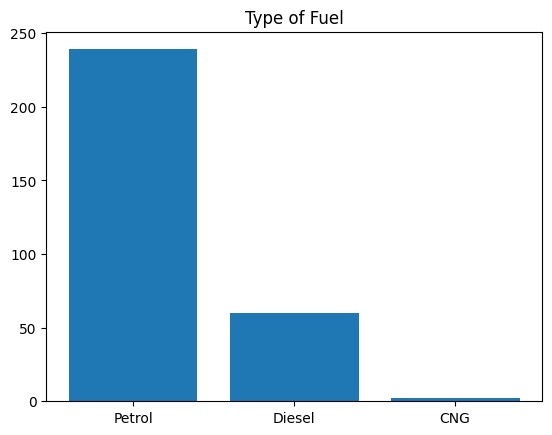

In [ ]:
plt.title('Type of Fuel')
plt.bar(x.index,x.values)
plt.show()

In [ ]:
y=df['Seller_Type'].value_counts()
y

,count
Seller_Type,
Dealer,195
Individual,106


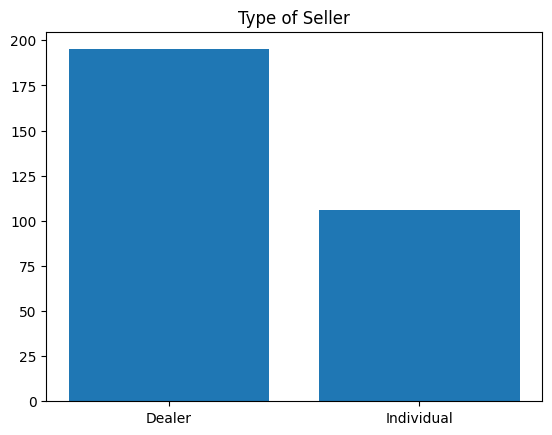

In [ ]:
plt.title("Type of Seller")
plt.bar(y.index,y.values)
plt.show()

In [ ]:
Number_of_previous=df["Owner"].value_counts()
Number_of_previous

,count
Owner,
0,290
1,10
3,1


In [ ]:
d=px.bar(Number_of_previous,title="Number of Previous Owners ")
d.show()

In [ ]:
Age = []
for i in df['Year']:
    Age.append(2019 - i)  # Calculate age by subtracting year from 2019
df.insert(2, 'Age', Age)  # Insert new 'Age' column into df
df.drop(columns=['Car_Name', 'Year'], inplace=True)  # Drop 'Car_Name' and 'Year' columns

In [ ]:
df

,Age,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,6,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,8,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,5,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,3,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,4,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,10,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
categorical_attr = ['Fuel_Type', 'Seller_Type', 'Transmission']
df[categorical_attr] = df[categorical_attr].apply(le.fit_transform, axis=0)
df.insert(8, 'Fuel_Type_n', df.Fuel_Type+2)
df.drop(columns=['Fuel_Type'],inplace=True)
df.insert(8, 'Seller_Type_n', df.Seller_Type+2)
df.drop(columns=['Seller_Type'],inplace=True)
df.insert(8, 'Transmission_n', df.Transmission+2)
df.drop(columns=['Transmission'],inplace=True)
df.insert(8, 'Owner_n', df.Owner+2)
df.drop(columns=['Owner'],inplace=True)
df

,Age,Selling_Price,Present_Price,Kms_Driven,Fuel_Type_n,Seller_Type_n,Transmission_n,Owner_n
0,5,3.35,5.59,27000,4,2,3,2
1,6,4.75,9.54,43000,3,2,3,2
2,2,7.25,9.85,6900,4,2,3,2
3,8,2.85,4.15,5200,4,2,3,2
4,5,4.60,6.87,42450,3,2,3,2
...,...,...,...,...,...,...,...,...
296,3,9.50,11.60,33988,3,2,3,2
297,4,4.00,5.90,60000,4,2,3,2
298,10,3.35,11.00,87934,4,2,3,2
299,2,11.50,12.50,9000,3,2,3,2


In [ ]:
x=df.drop(columns=['Selling_Price'])
y=df['Selling_Price']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
scaler=preprocessing.StandardScaler()
x_train_trf=scaler.fit_transform(x_train)
x_test_trf=scaler.transform(x_test)

In [ ]:
model=LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(x_train_trf,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test_trf)

In [ ]:
r2_score(y_test,y_pred)


0.9134181721224686